In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [2]:
df= pd.read_csv("drug200.csv")

In [3]:
df.head(10)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,DrugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,DrugY
9,43,M,LOW,NORMAL,19.368,DrugY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.315000,16.544315,15.000,31.0000,45.0000,58.00,74.000
Na_to_K,200.0,16.084485,7.223956,6.269,10.4455,13.9365,19.38,38.247


In [20]:
categoric_col= df.select_dtypes(exclude="number").columns

In [21]:
categoric_col

Index(['Sex', 'BP', 'Cholesterol', 'Drug'], dtype='object')

In [28]:
unique_array = []
for i in categoric_col:
    unique_array.append(df[i].unique())
print("Unique Values \n ",unique_array)

Unique Values 
  [array(['F', 'M'], dtype=object), array(['HIGH', 'LOW', 'NORMAL'], dtype=object), array(['HIGH', 'NORMAL'], dtype=object), array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)]


In [29]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder

In [33]:
ordinal_encoder = OrdinalEncoder(categories=[
    ['HIGH', 'LOW', 'NORMAL'],
])
ordinal_encoder2 = OrdinalEncoder(categories=[
    ['HIGH', 'NORMAL'],
])

In [34]:
df[["BP"]] = ordinal_encoder.fit_transform(df[["BP"]])
df[["Cholesterol"]] = ordinal_encoder2.fit_transform(df[["Cholesterol"]])

In [35]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,0.0,0.0,25.355,DrugY
1,47,M,1.0,0.0,13.093,drugC
2,47,M,1.0,0.0,10.114,drugC
3,28,F,2.0,0.0,7.798,drugX
4,61,F,1.0,0.0,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,1.0,0.0,11.567,drugC
196,16,M,1.0,0.0,12.006,drugC
197,52,M,2.0,0.0,9.894,drugX
198,23,M,2.0,1.0,14.020,drugX


In [36]:
label_encoder = LabelEncoder()

In [41]:
df["Drug"]=label_encoder.fit_transform(df["Drug"])

In [43]:
df["Sex"]=label_encoder.fit_transform(df["Sex"])

In [44]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0.0,0.0,25.355,0
1,47,1,1.0,0.0,13.093,3
2,47,1,1.0,0.0,10.114,3
3,28,0,2.0,0.0,7.798,4
4,61,0,1.0,0.0,18.043,0
...,...,...,...,...,...,...
195,56,0,1.0,0.0,11.567,3
196,16,1,1.0,0.0,12.006,3
197,52,1,2.0,0.0,9.894,4
198,23,1,2.0,1.0,14.020,4


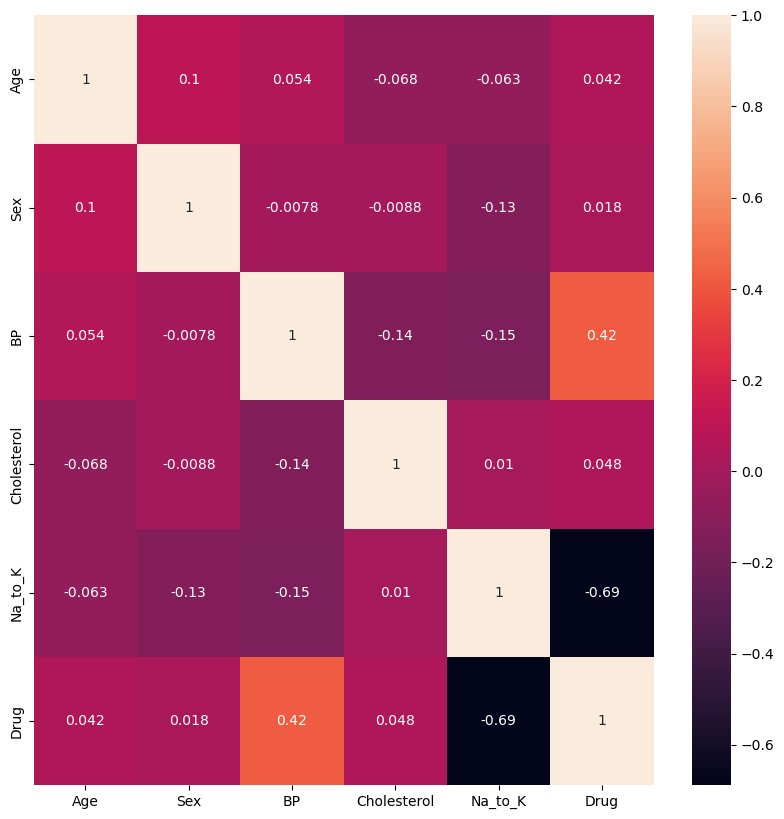

In [45]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [55]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [48]:
X= df.drop("Drug",axis=1)
y=df["Drug"]

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [54]:
DecisionTreeClassifier()

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
param_grid = {
    "criterion" : ['gini',"entropy", "log_loss"],
    "splitter" : ["best", "random"],
    "max_depth" : [3,4,5,7,10,20,None]
}

In [58]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid=param_grid,cv=5,scoring="accuracy")

In [59]:
grid.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 4, ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [60]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 4, 'splitter': 'best'}

In [62]:
y_pred = grid.predict(X_test)

In [64]:
print("Score : ",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Confusion Matrix : ",confusion_matrix(y_test,y_pred))


Score :  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        15

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Confusion Matrix :  [[20  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  6  0]
 [ 0  0  0  0 15]]
